In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm
from scipy.stats import skew, kurtosis

In [2]:
max='../data/processed/df_max.xlsx'
mean='../data/processed/df_mean.xlsx'

In [3]:
df_max = pd.read_excel(max)
df_mean = pd.read_excel(mean)

In [4]:
df_max_boxcox=pd.read_csv('../data/master/intact_boxcox_max.csv')
df_mean_boxcox=pd.read_csv('../data/master/intact_boxcox_mean.csv')

In [5]:
df_max_yeojohnson=pd.read_csv('../data/master/intact_yeojohnson_max.csv')
df_mean_yeojohnson=pd.read_csv('../data/master/intact_yeojohnson_mean.csv')

In [6]:
FEATURES = ['VAR_STD','Range','Energy','Peak_to_Peak','VAR','Max','MNF','SSC']

# Comparación de estadísticas antes/después de cada transformación.

## Funciones

In [7]:


def calcular_sesgo(df, features=None, n_channels=8,
                   group_by=None, pooled=False,
                   robust=False, min_n=30, extra_stats=True):
    """
    Calcula el sesgo de features EMG por canal (o agregando canales).

    group_by : lista de columnas para segmentar, ej. ['origin_db'] o
               ['origin_db','stimulus']. None = todo el dataset junto.
    pooled   : True agrupa los 8 canales en una sola distribución por feature.
    robust   : True añade el sesgo de Bowley (basado en cuartiles), insensible
               a colas extremas. Útil cuando Fisher-Pearson se dispara.
    min_n    : mínimo de observaciones para reportar; por debajo devuelve NaN.
    """
    if features is None:
        features = ['VAR_STD','Range','Energy','Peak_to_Peak','VAR','Max','MNF','SSC']

    def _stats(v):
        v = v[np.isfinite(v)]
        n = v.size
        if n < min_n:
            return dict(n=n, skew=np.nan)
        d = dict(n=n, skew=skew(v, bias=False))
        if extra_stats:
            d.update(mean=v.mean(), median=np.median(v), std=v.std(ddof=1),
                     kurtosis=kurtosis(v, bias=False),
                     pct_zeros=(v == 0).mean())
        if robust:
            q1, q2, q3 = np.percentile(v, [25, 50, 75])
            iqr = q3 - q1
            d['skew_bowley'] = (q3 + q1 - 2*q2) / iqr if iqr > 0 else np.nan
        return d

    grupos = df.groupby(group_by, dropna=False) if group_by else [((), df)]
    filas = []

    for llave, sub in grupos:
        llave = llave if isinstance(llave, tuple) else (llave,)
        meta = dict(zip(group_by or [], llave))

        for feat in features:
            cols = [f'Channel {ch}_{feat}' for ch in range(1, n_channels+1)]
            cols = [c for c in cols if c in sub.columns]
            if not cols:
                continue

            if pooled:
                filas.append({**meta, 'feature': feat, 'channel': 'all',
                              **_stats(sub[cols].to_numpy(dtype=float).ravel())})
            else:
                for c in cols:
                    ch = int(c.split(' ')[1].split('_')[0])
                    filas.append({**meta, 'feature': feat, 'channel': ch,
                                  **_stats(sub[c].to_numpy(dtype=float))})

    return pd.DataFrame(filas)

In [8]:
def comparar_agregadores(dfs, features, n_channels=8, col_stim='stimulus'):
    """
    dfs : {'Media': df_mean, 'Máximo': df_max}
    Devuelve eta² por feature × canal × enfoque: qué fracción de la varianza
    total explica el estímulo. Mayor = los agarres se distinguen mejor.
    """
    filas = []
    for nombre, df in dfs.items():
        for feat in features:
            for ch in range(1, n_channels+1):
                col = f'Channel {ch}_{feat}'
                if col not in df.columns:
                    continue
                g = [x[col].dropna().to_numpy() for _, x in df.groupby(col_stim)]
                g = [x for x in g if len(x) > 2]
                if len(g) < 2:
                    continue
                todos = np.concatenate(g); gm = todos.mean()
                ss_b = sum(len(x)*(x.mean()-gm)**2 for x in g)
                ss_t = ((todos-gm)**2).sum()
                filas.append({'enfoque': nombre, 'Feature': feat, 'Channel': ch,
                              'eta2': ss_b/ss_t if ss_t > 0 else np.nan,
                              'cv': todos.std()/abs(gm) if gm else np.nan})
    return pd.DataFrame(filas)


def plot_agregadores(df_sep, features, metrica='eta2'):
    colors = {'Media':'#3d5a99', 'Máximo':'#c1663d'}
    enfoques = [e for e in colors if e in set(df_sep.enfoque)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7),
                                   gridspec_kw={'width_ratios':[1.4, 1]})

    # barras por feature
    x = np.arange(len(features)); w = .38
    for j, e in enumerate(enfoques):
        vals = [df_sep.loc[(df_sep.Feature==f) & (df_sep.enfoque==e),
                           metrica].median() for f in features]
        b = ax1.bar(x + (j-.5)*w, vals, w*.92, color=colors[e],
                    edgecolor='white', linewidth=1.2, zorder=3, label=e)
        ax1.bar_label(b, fmt='%.3f', fontsize=10, fontweight='bold', padding=3)
    ax1.set_xticks(x); ax1.set_xticklabels(features, rotation=30, ha='right', fontsize=12)
    ax1.set_ylabel('η²  (varianza explicada por el estímulo)', fontsize=13)
    ax1.set_title('Separabilidad entre agarres por feature',
                  fontweight='bold', fontsize=15)
    ax1.grid(axis='y', alpha=.25, zorder=0); ax1.set_axisbelow(True)
    ax1.legend(fontsize=13, frameon=False)
    for s in ('top','right'): ax1.spines[s].set_visible(False)

    # scatter pareado: cada punto = feature × canal
    w2 = df_sep.pivot_table(index=['Feature','Channel'], columns='enfoque',
                            values=metrica).dropna()
    gana = (w2[enfoques[1]] > w2[enfoques[0]]).mean()
    sns.scatterplot(data=w2.reset_index(), x=enfoques[0], y=enfoques[1],
                    hue='Feature', s=70, alpha=.8, edgecolor='white', ax=ax2)
    lim = (0, max(w2.to_numpy().max()*1.1, .05))
    ax2.plot(lim, lim, 'k--', lw=1.5, zorder=0)
    ax2.set_xlim(lim); ax2.set_ylim(lim); ax2.set_aspect('equal')
    ax2.set_title(f'{enfoques[1]} mejor en {gana:.0%} de los casos',
                  fontweight='bold', fontsize=15)
    ax2.set_xlabel(f'η² — {enfoques[0]}', fontsize=13)
    ax2.set_ylabel(f'η² — {enfoques[1]}', fontsize=13)
    ax2.legend(fontsize=9, loc='upper left', framealpha=.9)
    ax2.grid(alpha=.25)

    fig.suptitle('Media vs Máximo por ventana — ¿cuál conserva mejor la información de agarre?',
                 fontsize=19, fontweight='bold', y=1.01)
    fig.tight_layout(); plt.show()
    return w2

In [9]:
def compare_transform_stats(df_original, transformados, variable,
                            n_channels=8, group_by=('Stimulus'), min_n=15,
                            umbral_sesgo=0.1, check_alignment=True):
    """
    df_original  : DataFrame sin transformar
    transformados: dict {'Box-Cox': df_bc, 'Yeo-Johnson': df_yj}
    umbral_sesgo : si |Sesgo_original| < umbral, Pct_cambio_sesgo = NaN
                   (el porcentaje es inestable cuando el sesgo base ~ 0)
    """
    group_by = list(group_by)
    filas = []

    def _sub(df, llave):
        m = np.ones(len(df), dtype=bool)
        for k, v in zip(group_by, llave):
            m &= (df[k] == v).to_numpy()
        return df[m]

    for llave, orig_g in df_original.groupby(group_by, dropna=False):
        llave = llave if isinstance(llave, tuple) else (llave,)
        meta = dict(zip(group_by, llave))

        for ch in range(1, n_channels + 1):
            col = f'Channel {ch}_{variable}'
            if col not in orig_g.columns:
                continue

            o = orig_g[col].dropna()
            s_o = o.skew() if len(o) >= min_n else np.nan
            base = dict(**meta, Channel=ch, Feature=variable)

            # --- fila de referencia ---
            filas.append({**base, 'transformacion': 'Original', 'n': len(o),
                          'Sesgo': s_o, 'Pct_cambio_sesgo': 0.0,
                          'Mejora': pd.NA, 'Cruza_cero': pd.NA,
                          'Media': o.mean(), 'Varianza': o.var()})

            # --- una fila por transformación ---
            for nombre, df_t in transformados.items():
                trans_g = _sub(df_t, llave)
                if check_alignment and len(orig_g) != len(trans_g):
                    raise ValueError(f'{nombre} {meta}: {len(orig_g)} vs {len(trans_g)} filas')
                if col not in trans_g.columns:
                    continue

                t = trans_g[col].dropna()
                s_t = t.skew() if len(t) >= min_n else np.nan

                if np.isfinite(s_o) and np.isfinite(s_t) and abs(s_o) >= umbral_sesgo:
                    pct = (abs(s_t) - abs(s_o)) / abs(s_o) * 100
                    mejora = abs(s_t) < abs(s_o)
                    cruza = np.sign(s_o) != np.sign(s_t)
                else:
                    pct, mejora, cruza = np.nan, pd.NA, pd.NA

                filas.append({**base, 'transformacion': nombre, 'n': len(t),
                              'Sesgo': s_t, 'Pct_cambio_sesgo': pct,
                              'Mejora': mejora, 'Cruza_cero': cruza,
                              'Media': t.mean(), 'Varianza': t.var()})

    cols = group_by + ['Channel', 'Feature', 'transformacion', 'n',
                       'Sesgo', 'Pct_cambio_sesgo', 'Mejora', 'Cruza_cero',
                       'Media', 'Varianza']
    return pd.DataFrame(filas)[cols].round(4)

In [10]:
def heatmap_sesgo(df_comparacion, features=None, agg='median',
                  modo='norm_global', vmin=None, vmax=None, umbral=0.5,
                  separar=('MNF','SSC'), cmap='RdYlGn_r', figsize=None):
    """
    modo : 'log'         -> escala de color logarítmica sobre |sesgo| crudo.
           'norm_global' -> divide los tres paneles por el MISMO máximo (0-1).
                            Mantiene comparabilidad entre paneles.
           'norm_panel'  -> cada panel dividido por su propio máximo (0-1).
                            NO comparable entre paneles — solo muestra el
                            patrón interno de cada transformación.
    """
    d = df_comparacion.dropna(subset=['Sesgo']).copy()
    d['abs'] = d['Sesgo'].abs()
    if features is not None:
        d = d[d.Feature.isin(features)]

    orden = [t for t in ['Original','Box-Cox','Yeo-Johnson']
             if t in set(d.transformacion)]

    feats = list(features) if features is not None else sorted(set(d.Feature))
    abajo  = [f for f in feats if f in (separar or ())]
    arriba = [f for f in feats if f not in abajo]
    feats  = arriba + abajo

    crudos = {t: d[d.transformacion == t]
                 .pivot_table(index='Feature', columns='stimulus',
                              values='abs', aggfunc=agg).reindex(feats)
              for t in orden}

    ref_global = float(max(np.nanmax(p.to_numpy()) for p in crudos.values()))

    if modo == 'norm_global':
        pivots = {t: p / ref_global for t, p in crudos.items()}
        refs   = {t: ref_global for t in orden}
        etiq, fmt, norm = f'|Sesgo| / {ref_global:.2f}  (máximo global)', '.3f', None
        vmin, vmax = 0, 1
    elif modo == 'norm_panel':
        refs   = {t: float(np.nanmax(p.to_numpy())) for t, p in crudos.items()}
        pivots = {t: p / refs[t] for t, p in crudos.items()}
        etiq, fmt, norm = '|Sesgo| / máximo del panel', '.3f', None
        vmin, vmax = 0, 1
    else:
        pivots, refs = crudos, {t: None for t in orden}
        todos = np.concatenate([p.to_numpy().ravel() for p in pivots.values()])
        todos = todos[np.isfinite(todos) & (todos > 0)]
        vmin = vmin or todos.min()*.9
        vmax = vmax or todos.max()*1.1
        norm = LogNorm(vmin=vmin, vmax=vmax)
        etiq, fmt = f'|Sesgo| ({agg}) — escala log', '.2f'

    figsize = figsize or (8.5*len(orden), 1.0*len(feats) + 3.4)
    fig, axes = plt.subplots(1, len(orden), figsize=figsize, sharey=True)
    axes = np.atleast_1d(axes)

    for ax, t in zip(axes, orden):
        p, crudo = pivots[t], crudos[t]
        sns.heatmap(p, ax=ax, cmap=cmap, norm=norm,
                    vmin=None if norm else vmin, vmax=None if norm else vmax,
                    annot=True, fmt=fmt, annot_kws={'size':11,'weight':'bold'},
                    linewidths=1.2, linecolor='white', cbar=(ax is axes[-1]),
                    cbar_kws={'label':etiq,'pad':.02,'aspect':30}
                              if ax is axes[-1] else None)
        if abajo:
            ax.axhline(len(arriba), color='black', lw=3)

        med    = np.nanmedian(crudo.to_numpy())
        pct_ok = np.nanmean(crudo.to_numpy() < umbral) * 100
        extra  = (f'  ·  máx {refs[t]:.2f}' if modo == 'norm_panel' else '')
        ax.set_title(t, fontweight='bold', fontsize=16, pad=12)
        ax.set_xlabel('Estímulo', fontsize=13); ax.set_ylabel('')
        ax.tick_params(axis='y', rotation=0, labelsize=12)
        ax.tick_params(axis='x', labelsize=12)

    aviso = ('  ⚠ escala propia por panel — NO comparable entre paneles'
             if modo == 'norm_panel' else '')
    fig.suptitle(f'Magnitud del sesgo por feature y estímulo [{modo}]{aviso}',
                 fontsize=18, fontweight='bold', y=1.0)
    fig.tight_layout(rect=[0,0,1,.94], w_pad=2.0); plt.show()

In [11]:
def boxplot_sesgo_por_feature(df_comparacion, features, umbral=0.5,
                              ncols=4, norm_por='feature', figsize=None):
    """
    Un panel por feature; dentro, las 3 transformaciones normalizadas
    por su máximo → eje 0-1 en todos los paneles.

    norm_por : 'feature' -> el máximo se calcula por transformación DENTRO
                            de cada feature (cada panel se aprovecha al máximo).
               'global'  -> un solo máximo por transformación para toda la
                            figura (paneles comparables entre sí).
    """
    d = df_comparacion.dropna(subset=['Sesgo']).copy()
    d['abs'] = d['Sesgo'].abs()
    d = d[d.Feature.isin(features)]

    orden = [t for t in ['Original','Box-Cox','Yeo-Johnson']
             if t in set(d.transformacion)]
    colors = {'Original':'#999999','Box-Cox':'#3d5a99','Yeo-Johnson':'#4f9367'}

    if norm_por == 'global':
        g = {t: float(d.loc[d.transformacion == t, 'abs'].max()) for t in orden}
        refs = {(f, t): g[t] for f in features for t in orden}
    else:
        refs = {(f, t): float(d.loc[(d.Feature == f) &
                                    (d.transformacion == t), 'abs'].max())
                for f in features for t in orden}

    d['_ref'] = [refs.get((f, t), np.nan)
                 for f, t in zip(d.Feature, d.transformacion)]
    d['_y'] = d['abs'] / d['_ref']

    nrows = int(np.ceil(len(features)/ncols))
    figsize = figsize or (6.0*ncols, 4.8*nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize,
                             sharey=True, squeeze=False)
    axes = axes.flatten()

    for i, feat in enumerate(features):
        ax = axes[i]
        sns.boxplot(data=d[d.Feature == feat], x='stimulus', y='_y',
                    hue='transformacion', hue_order=orden, palette=colors,
                    ax=ax, showfliers=False, width=.78,
                    medianprops=dict(color='black', linewidth=1.5))

        for t in orden:                      # umbral por transformación
            r = refs.get((feat, t))
            if r and umbral/r < 1.02:
                ax.axhline(umbral/r, color=colors[t], ls=':', lw=1.7,
                           alpha=.9, zorder=0)

        ax.set_title(feat, fontweight='bold', fontsize=14, pad=8)
        ax.set_ylim(0, 1.04)
        ax.set_xlabel('Estímulo' if i >= len(features)-ncols else '', fontsize=11)
        ax.set_ylabel('|Sesgo| / máx' if i % ncols == 0 else '', fontsize=12)
        ax.grid(axis='y', alpha=.25); ax.set_axisbelow(True)
        for s in ('top','right'): ax.spines[s].set_visible(False)
        if ax.get_legend(): ax.get_legend().remove()
        ax.tick_params(labelsize=10)

    for ax in axes[len(features):]: ax.set_visible(False)

    fig.legend(handles=[Patch(facecolor=colors[t], label=t) for t in orden],
               loc='upper center', bbox_to_anchor=(.5, .975), ncol=len(orden),
               fontsize=14, frameon=False)
    fig.suptitle('Sesgo por estímulo y feature — cada transformación normalizada por su máximo',
                 fontsize=18, fontweight='bold', y=1.0)
    fig.tight_layout(rect=[0,0,1,.945], h_pad=2.4, w_pad=1.2); plt.show()

In [12]:
def barras_reduccion(df_comparacion, features=None, n_channels=8,
                     umbral_orig=0.3, ylim=(0, 105), agg='median',
                     grid=(4, 2), figsize=None, ocultar_vacios=True):
    d = df_comparacion.dropna(subset=['Sesgo']).copy()
    d['abs'] = d['Sesgo'].abs()

    key = ['Feature','stimulus','Channel']
    base = d[d.transformacion=='Original'].set_index(key)['abs']
    d['base'] = pd.MultiIndex.from_frame(d[key]).map(base).to_numpy()

    excluidos = sorted(d.loc[d['base'] < umbral_orig, 'Feature'].unique())
    d = d[(d['base'] >= umbral_orig) & (d.transformacion != 'Original')]
    d['reduccion'] = (1 - d['abs']/d['base']) * 100

    feats = [f for f in (features or sorted(d.Feature.unique()))
             if f in set(d.Feature)]          # <- quita columnas vacías
    if excluidos:
        print(f'Excluidos (|sesgo original| < {umbral_orig}): {", ".join(excluidos)}')

    colors = {'Box-Cox':'#3d5a99','Yeo-Johnson':'#4f9367'}
    nrows, ncols = grid
    figsize = figsize or (11*ncols, 4.6*nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize,
                             sharey=True, sharex=True)
    axes = np.atleast_1d(axes).flatten()

    x = np.arange(len(feats)); width = .40

    for ch, ax in zip(range(1, n_channels+1), axes):
        sub = d[d.Channel == ch]
        for j, t in enumerate(['Box-Cox','Yeo-Johnson']):
            vals = [sub.loc[(sub.Feature==f) & (sub.transformacion==t),
                            'reduccion'].agg(agg) for f in feats]
            b = ax.bar(x + (j-.5)*width, vals, width*.92,
                       color=colors[t], edgecolor='white', linewidth=1.2, zorder=3)
            ax.bar_label(b, fmt='%.0f', fontsize=10, padding=3,
                         fontweight='bold', color='#333')

        ax.set_ylim(ylim)
        ax.set_yticks(range(0, 101, 20))
        ax.set_xticks(x)
        ax.set_xticklabels(feats, rotation=30, ha='right', fontsize=12)
        ax.set_title(f'Canal {ch}', fontweight='bold', fontsize=15, pad=10)
        ax.grid(axis='y', alpha=.25, zorder=0)
        ax.set_axisbelow(True)
        for lado in ('top','right'):
            ax.spines[lado].set_visible(False)
        ax.tick_params(labelsize=11)

    if ocultar_vacios:
        for ax in axes[n_channels:]:
            ax.set_visible(False)

    for i, ax in enumerate(axes[:n_channels]):
        if i % ncols == 0:
            ax.set_ylabel('% reducción del sesgo', fontsize=13)

    fig.legend(handles=[Patch(facecolor=c, label=t) for t, c in colors.items()],
               loc='upper center', bbox_to_anchor=(.5, .975), ncol=2,
               fontsize=15, frameon=False)
    fig.suptitle('Reducción del sesgo por canal y feature',
                 fontsize=20, fontweight='bold', y=1.005)
    fig.tight_layout(rect=[0, 0, 1, .955], h_pad=3.0, w_pad=2.5)
    plt.show()

In [13]:
calcular_sesgo(df_mean, pooled=True, robust=True, min_n=30)

,feature,channel,n,skew,mean,median,std,kurtosis,pct_zeros,skew_bowley
0,VAR_STD,all,5568,26.272369,2.445954e+06,0.022776,2.472944e+07,880.227421,0.0,0.997429
1,Range,all,5568,13.373171,3.203291e+02,0.150834,2.039798e+03,217.218411,0.0,0.969597
2,Energy,all,5568,21.587603,5.265520e+08,1.926620,4.297828e+09,622.392571,0.0,0.997804
3,Peak_to_Peak,all,5568,17.419592,2.869889e+04,0.633789,2.493488e+05,396.456467,0.0,0.984041
4,VAR,all,5568,16.395287,3.016392e+03,0.000171,2.101728e+04,430.607880,0.0,0.997789
5,Max,all,5568,14.512457,4.581891e+03,1.302555,3.445641e+04,278.921054,0.0,0.974464
6,MNF,all,5568,3.669640,5.019728e+04,5001.479623,1.634290e+05,12.997856,0.0,-0.710893
7,SSC,all,5568,3.748838,2.906834e+04,2760.972222,9.668531e+04,13.683084,0.0,-0.663188


In [14]:
calcular_sesgo(df_max, pooled=True, robust=True, min_n=30)

,feature,channel,n,skew,mean,median,std,kurtosis,pct_zeros,skew_bowley
0,VAR_STD,all,5568,21.364343,3.501593e+06,0.089298,2.680955e+07,639.231855,0.0,0.994427
1,Range,all,5568,10.875530,4.485890e+02,0.388892,2.205930e+03,157.215113,0.0,0.946662
2,Energy,all,5568,16.432815,7.237982e+08,6.007982,4.877641e+09,388.161203,0.0,0.996175
3,Peak_to_Peak,all,5568,17.203217,3.174659e+04,1.663150,2.502424e+05,389.947867,0.0,0.958028
4,VAR,all,5568,32.492187,9.187735e+03,0.000662,8.485531e+04,1526.769729,0.0,0.995777
5,Max,all,5568,14.321226,4.953335e+03,2.689794,3.458951e+04,273.999414,0.0,0.956835
6,MNF,all,5568,3.670218,5.056959e+04,5579.186582,1.633266e+05,13.004296,0.0,-0.725463
7,SSC,all,5568,3.749377,2.928176e+04,3063.666667,9.662787e+04,13.689442,0.0,-0.673325


In [15]:
df_sep = comparar_agregadores({'Media': df_mean, 'Máximo': df_max}, FEATURES)

## mean

In [16]:
df_comparacion = pd.concat([
    compare_transform_stats(df_mean,
                            {'Box-Cox': df_mean_boxcox, 'Yeo-Johnson': df_mean_yeojohnson},
                            feat,
                            group_by=('stimulus',),
                            min_n=15)
    for feat in FEATURES
], ignore_index=True)

In [17]:
del max

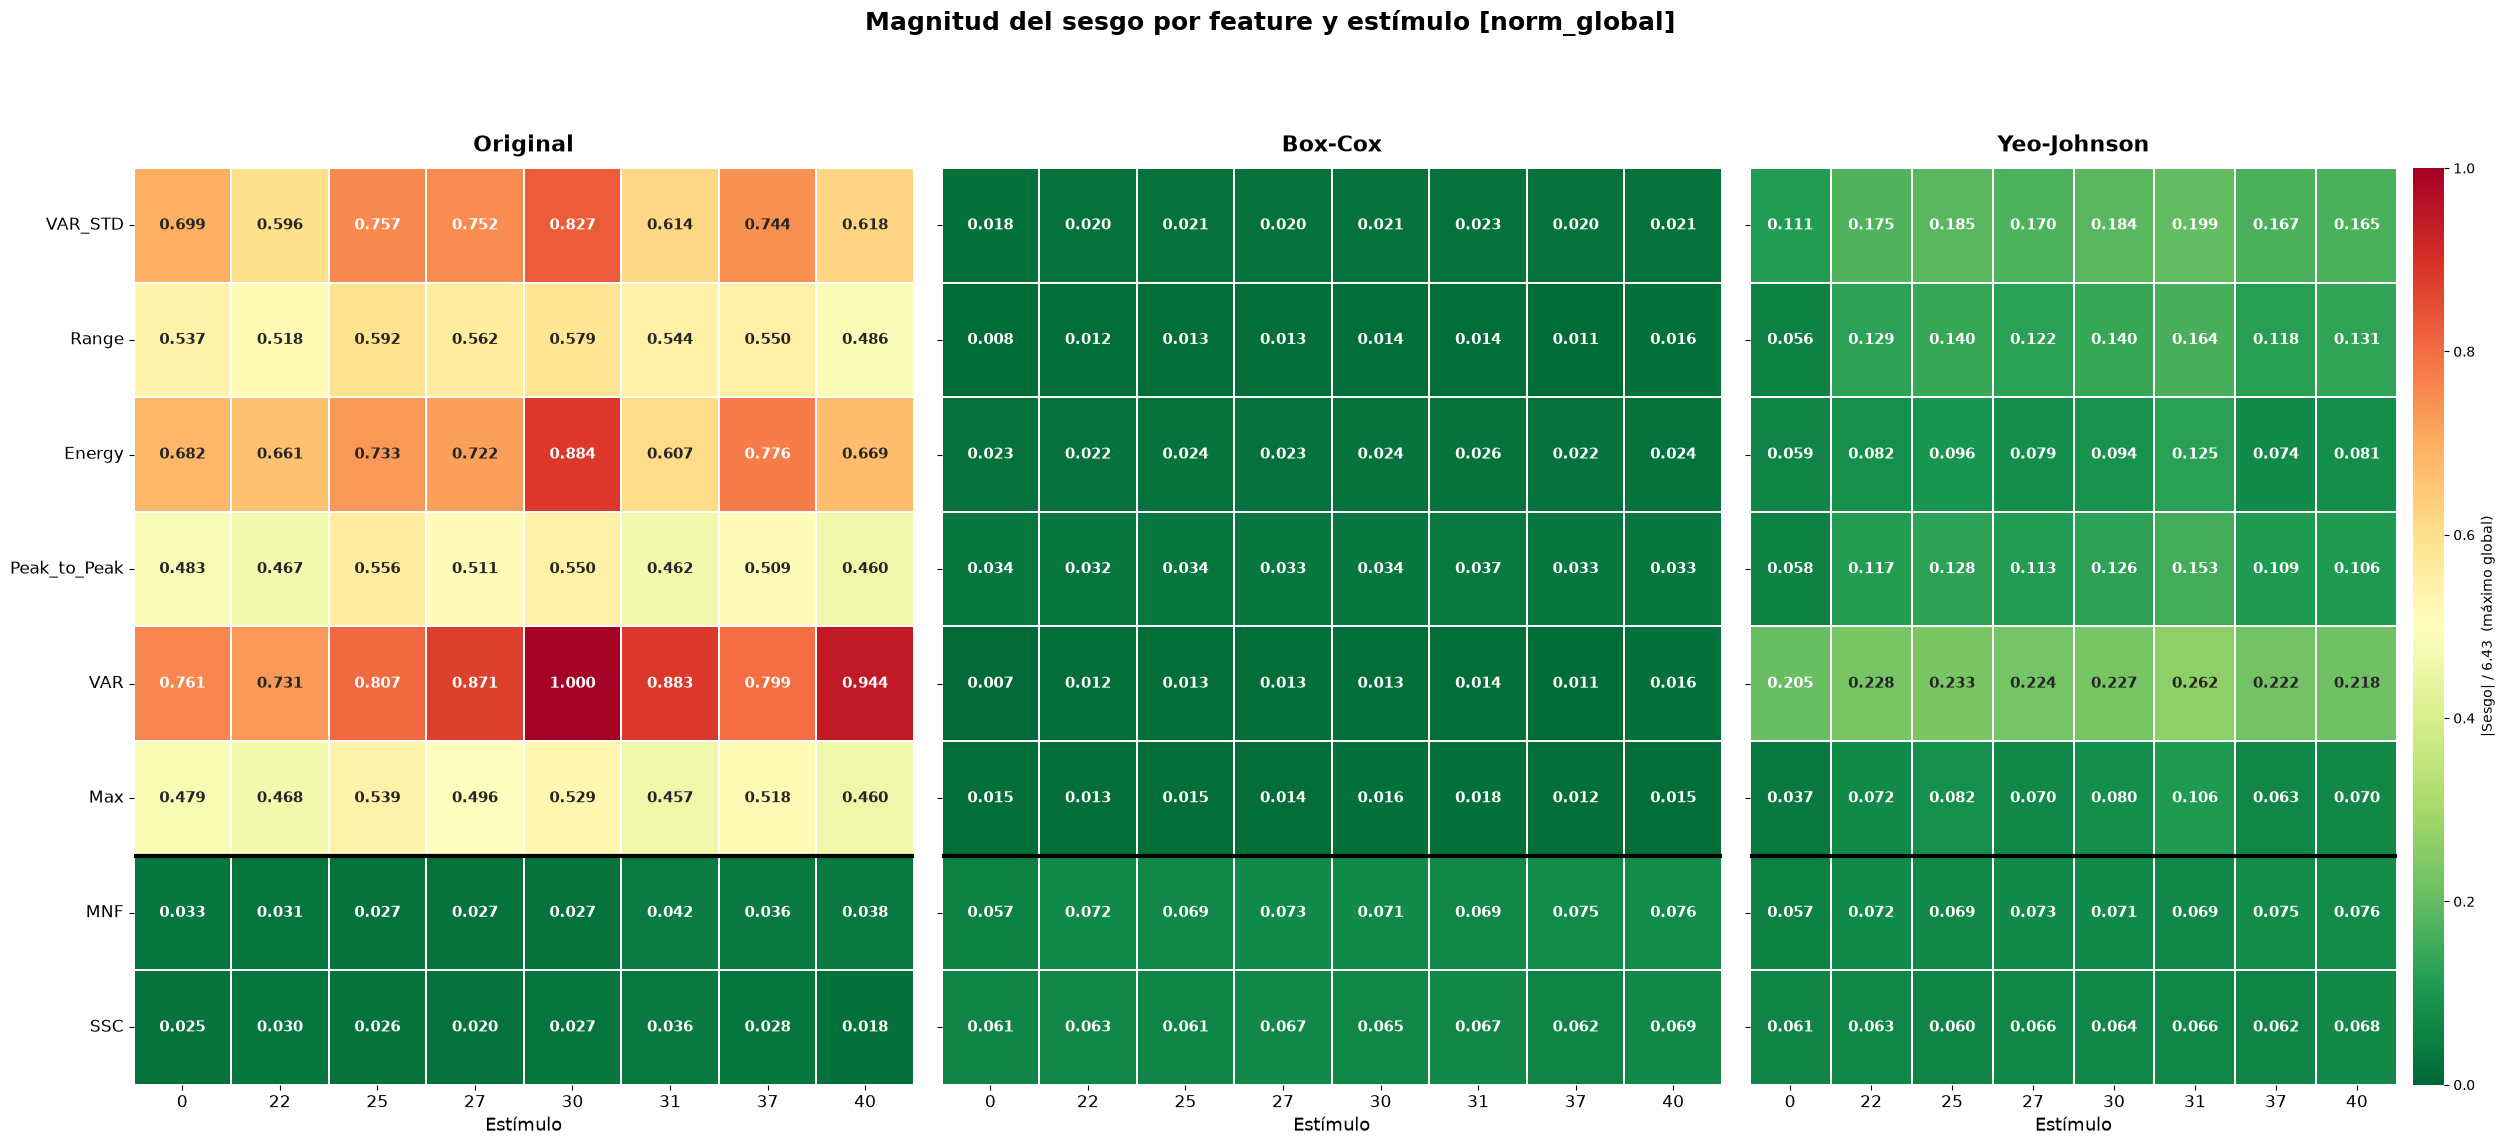

In [18]:
heatmap_sesgo(df_comparacion, FEATURES, modo='norm_global')

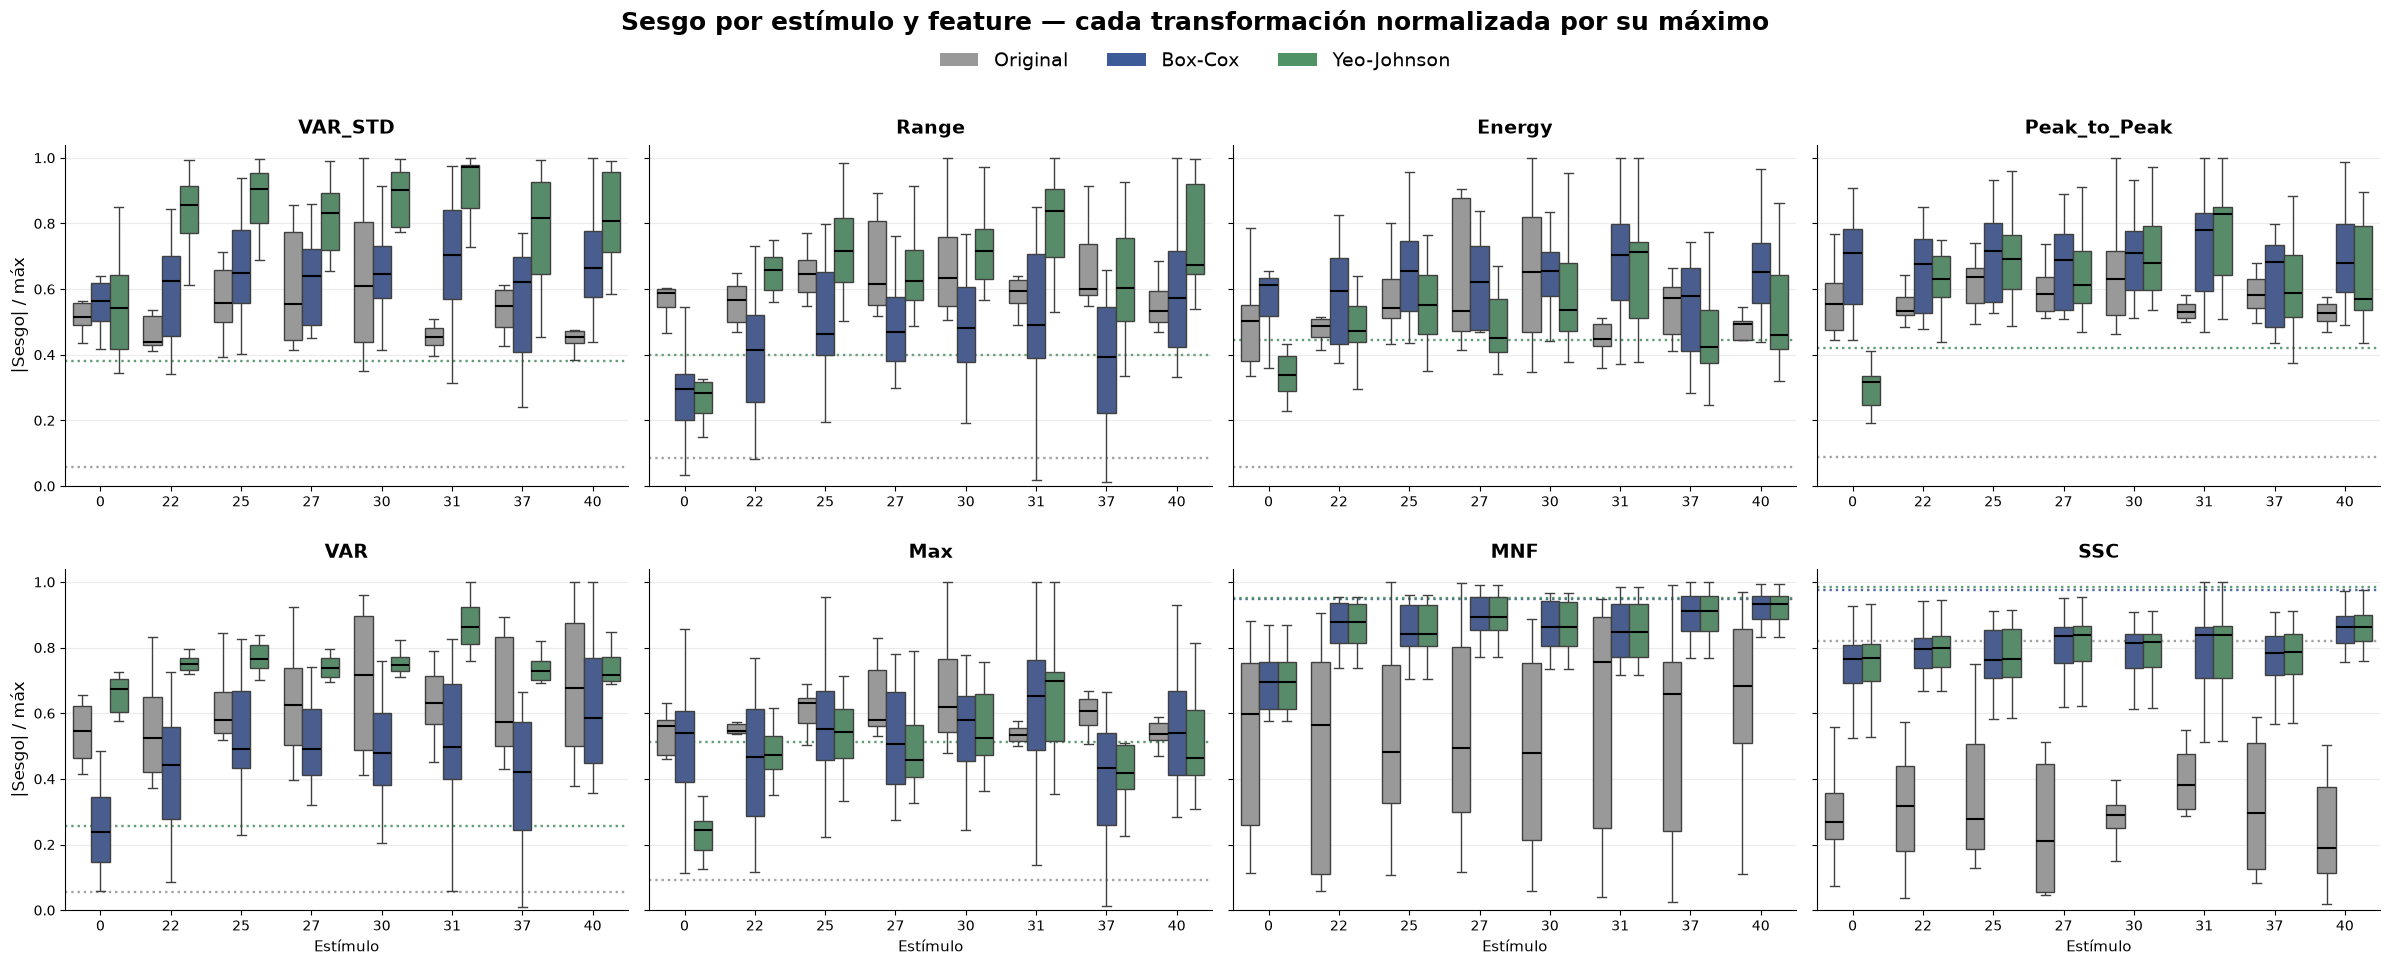

In [19]:
boxplot_sesgo_por_feature(df_comparacion, FEATURES)

Excluidos (|sesgo original| < 0.3): MNF, SSC


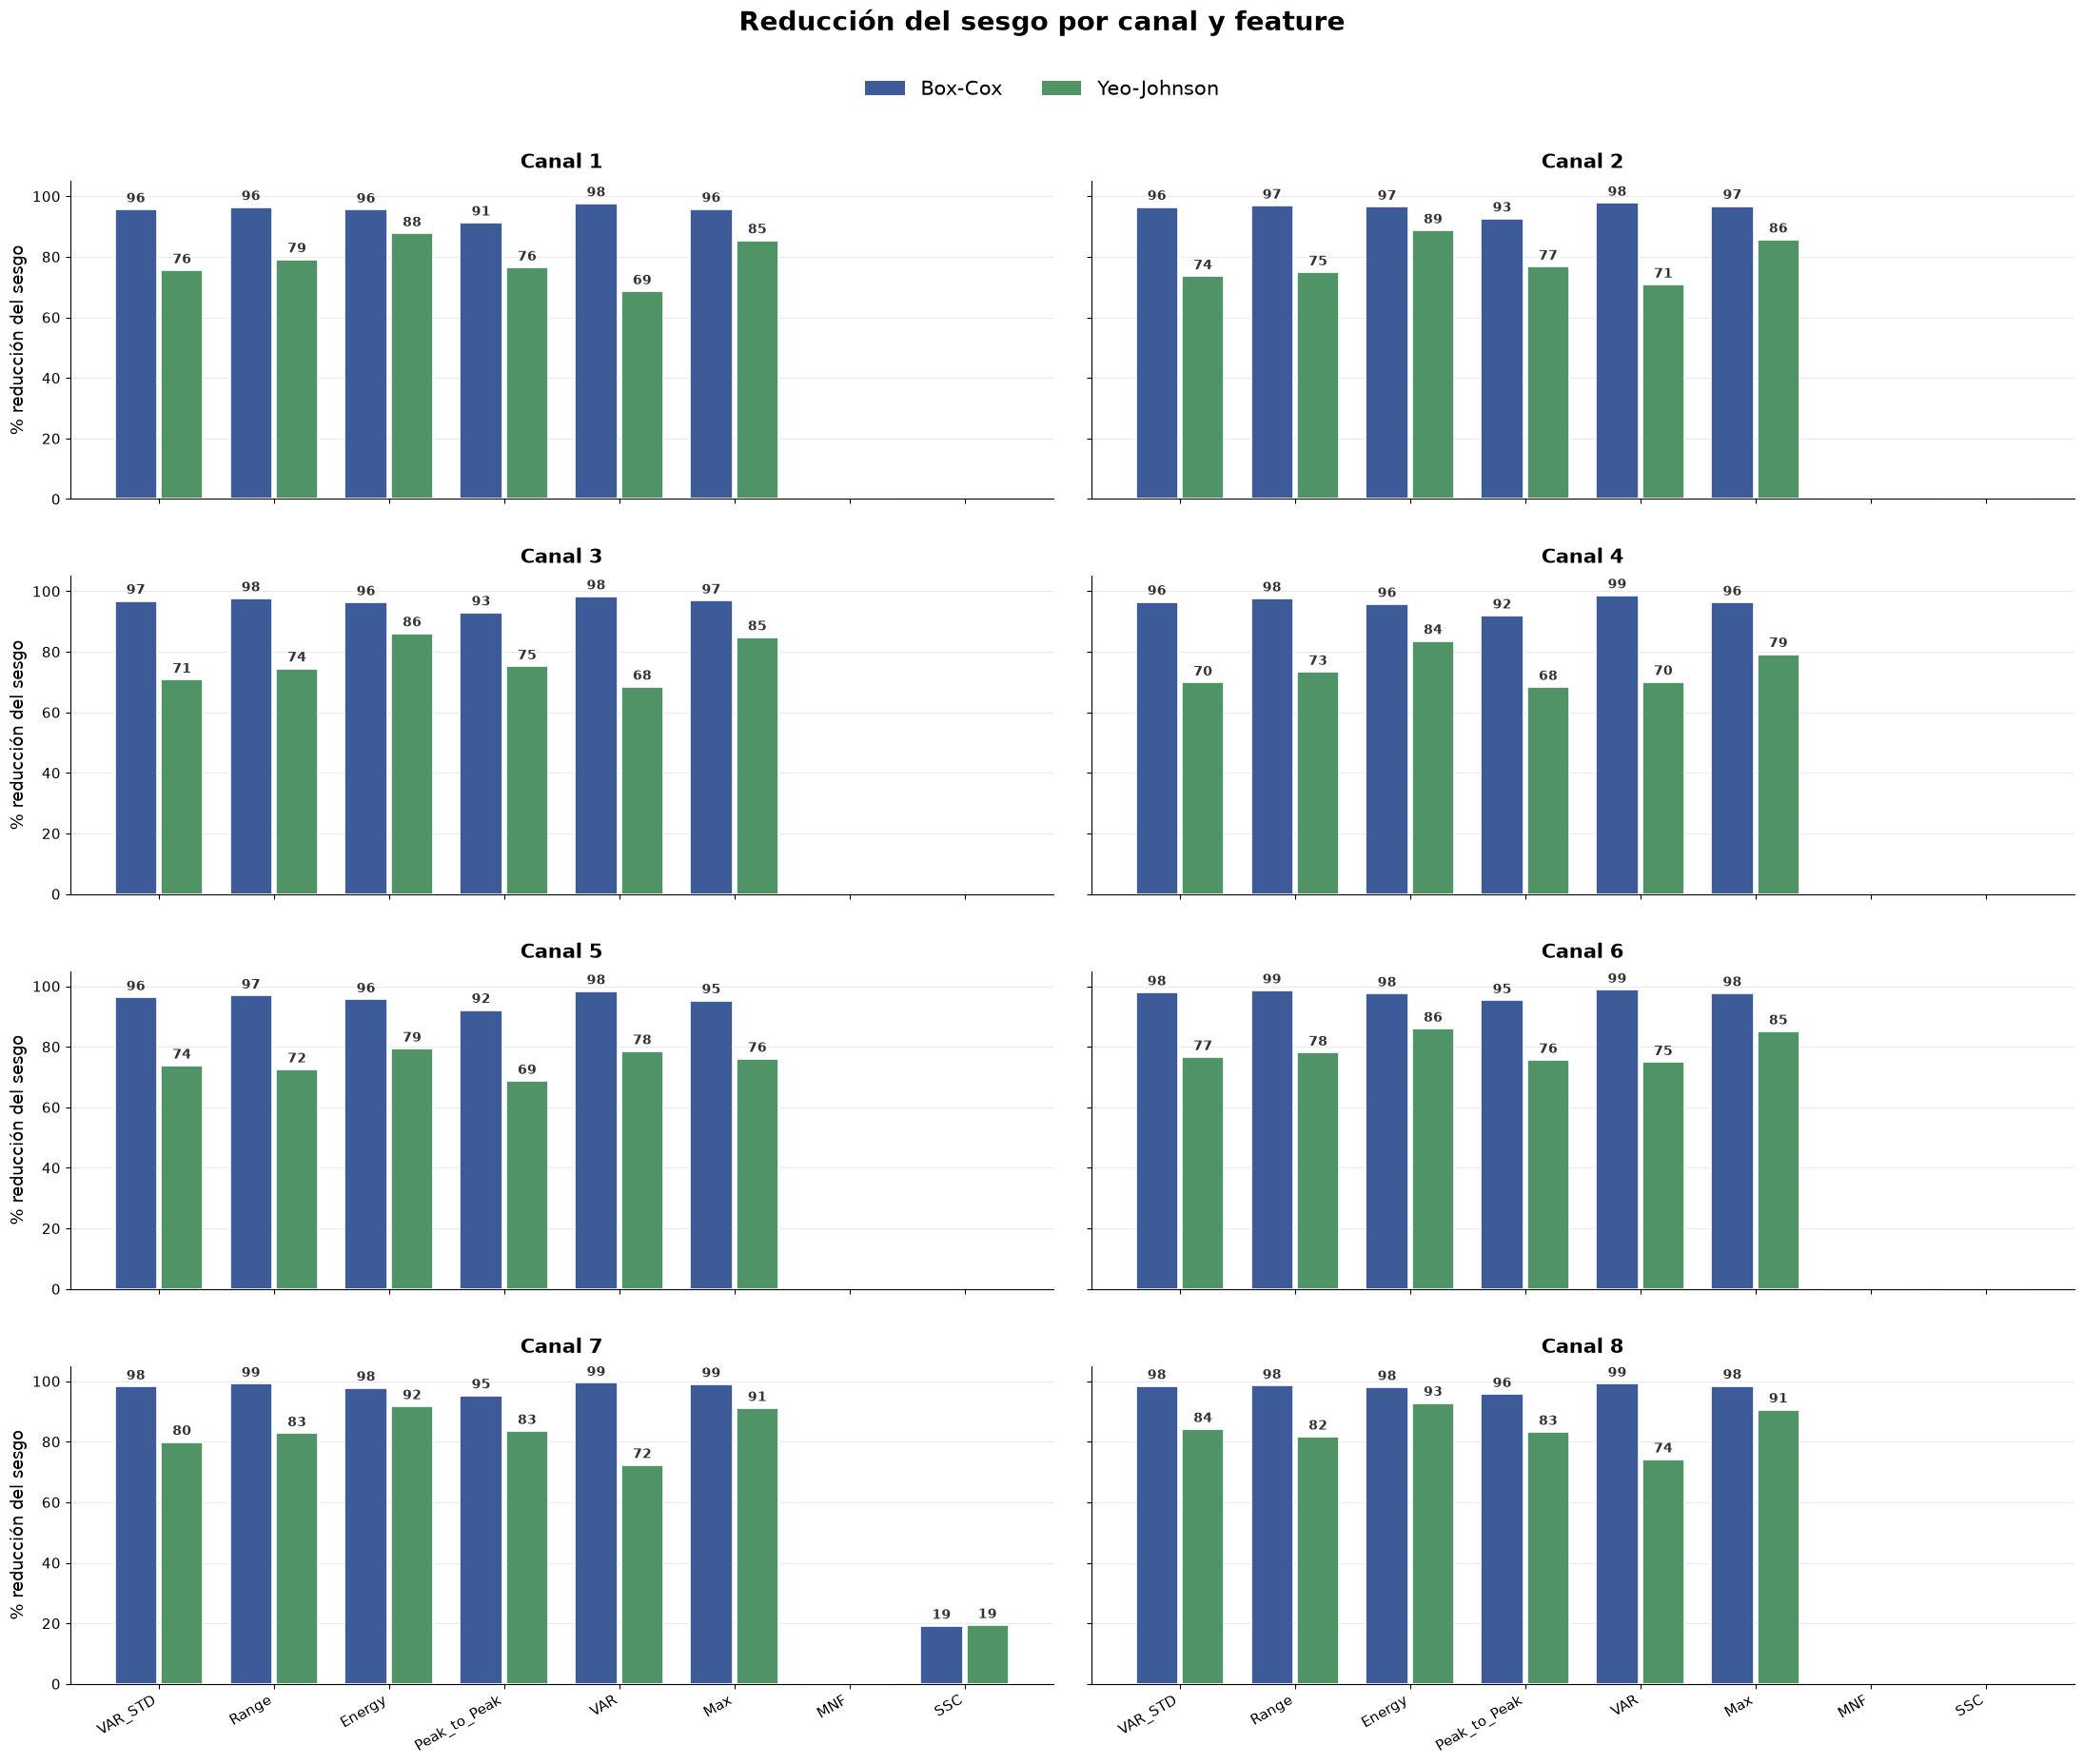

In [26]:
barras_reduccion(df_comparacion, FEATURES)

## Max

In [21]:
df_comparacion_max = pd.concat([
    compare_transform_stats(df_max,
                            {'Box-Cox': df_max_boxcox, 'Yeo-Johnson': df_max_yeojohnson},
                            feat,
                            group_by=('stimulus',),
                            min_n=15)
    for feat in FEATURES
], ignore_index=True)

In [22]:
df_comparacion_max

,stimulus,Channel,Feature,transformacion,n,Sesgo,Pct_cambio_sesgo,Mejora,Cruza_cero,Media,Varianza
0,0,1,VAR_STD,Original,87,4.4945,0.0000,<NA>,<NA>,3.780290e+07,1.755669e+16
1,0,1,VAR_STD,Box-Cox,87,0.1316,-97.0715,True,False,-2.807100e+00,1.421304e+02
2,0,1,VAR_STD,Yeo-Johnson,87,0.5776,-87.1484,True,False,2.163500e+00,5.981200e+00
3,0,2,VAR_STD,Original,87,4.4887,0.0000,<NA>,<NA>,1.090522e+07,1.403579e+15
4,0,2,VAR_STD,Box-Cox,87,0.1261,-97.1905,True,False,-4.524700e+00,1.686539e+02
...,...,...,...,...,...,...,...,...,...,...,...
1531,40,7,SSC,Box-Cox,87,-0.3523,NaN,<NA>,<NA>,5.070360e+01,6.067089e+02
1532,40,7,SSC,Yeo-Johnson,87,-0.3518,NaN,<NA>,<NA>,5.080990e+01,6.081827e+02
1533,40,8,SSC,Original,87,-0.1809,0.0000,<NA>,<NA>,2.023951e+03,2.253400e+06
1534,40,8,SSC,Box-Cox,87,-0.3819,111.0859,False,False,6.254970e+01,9.667113e+02


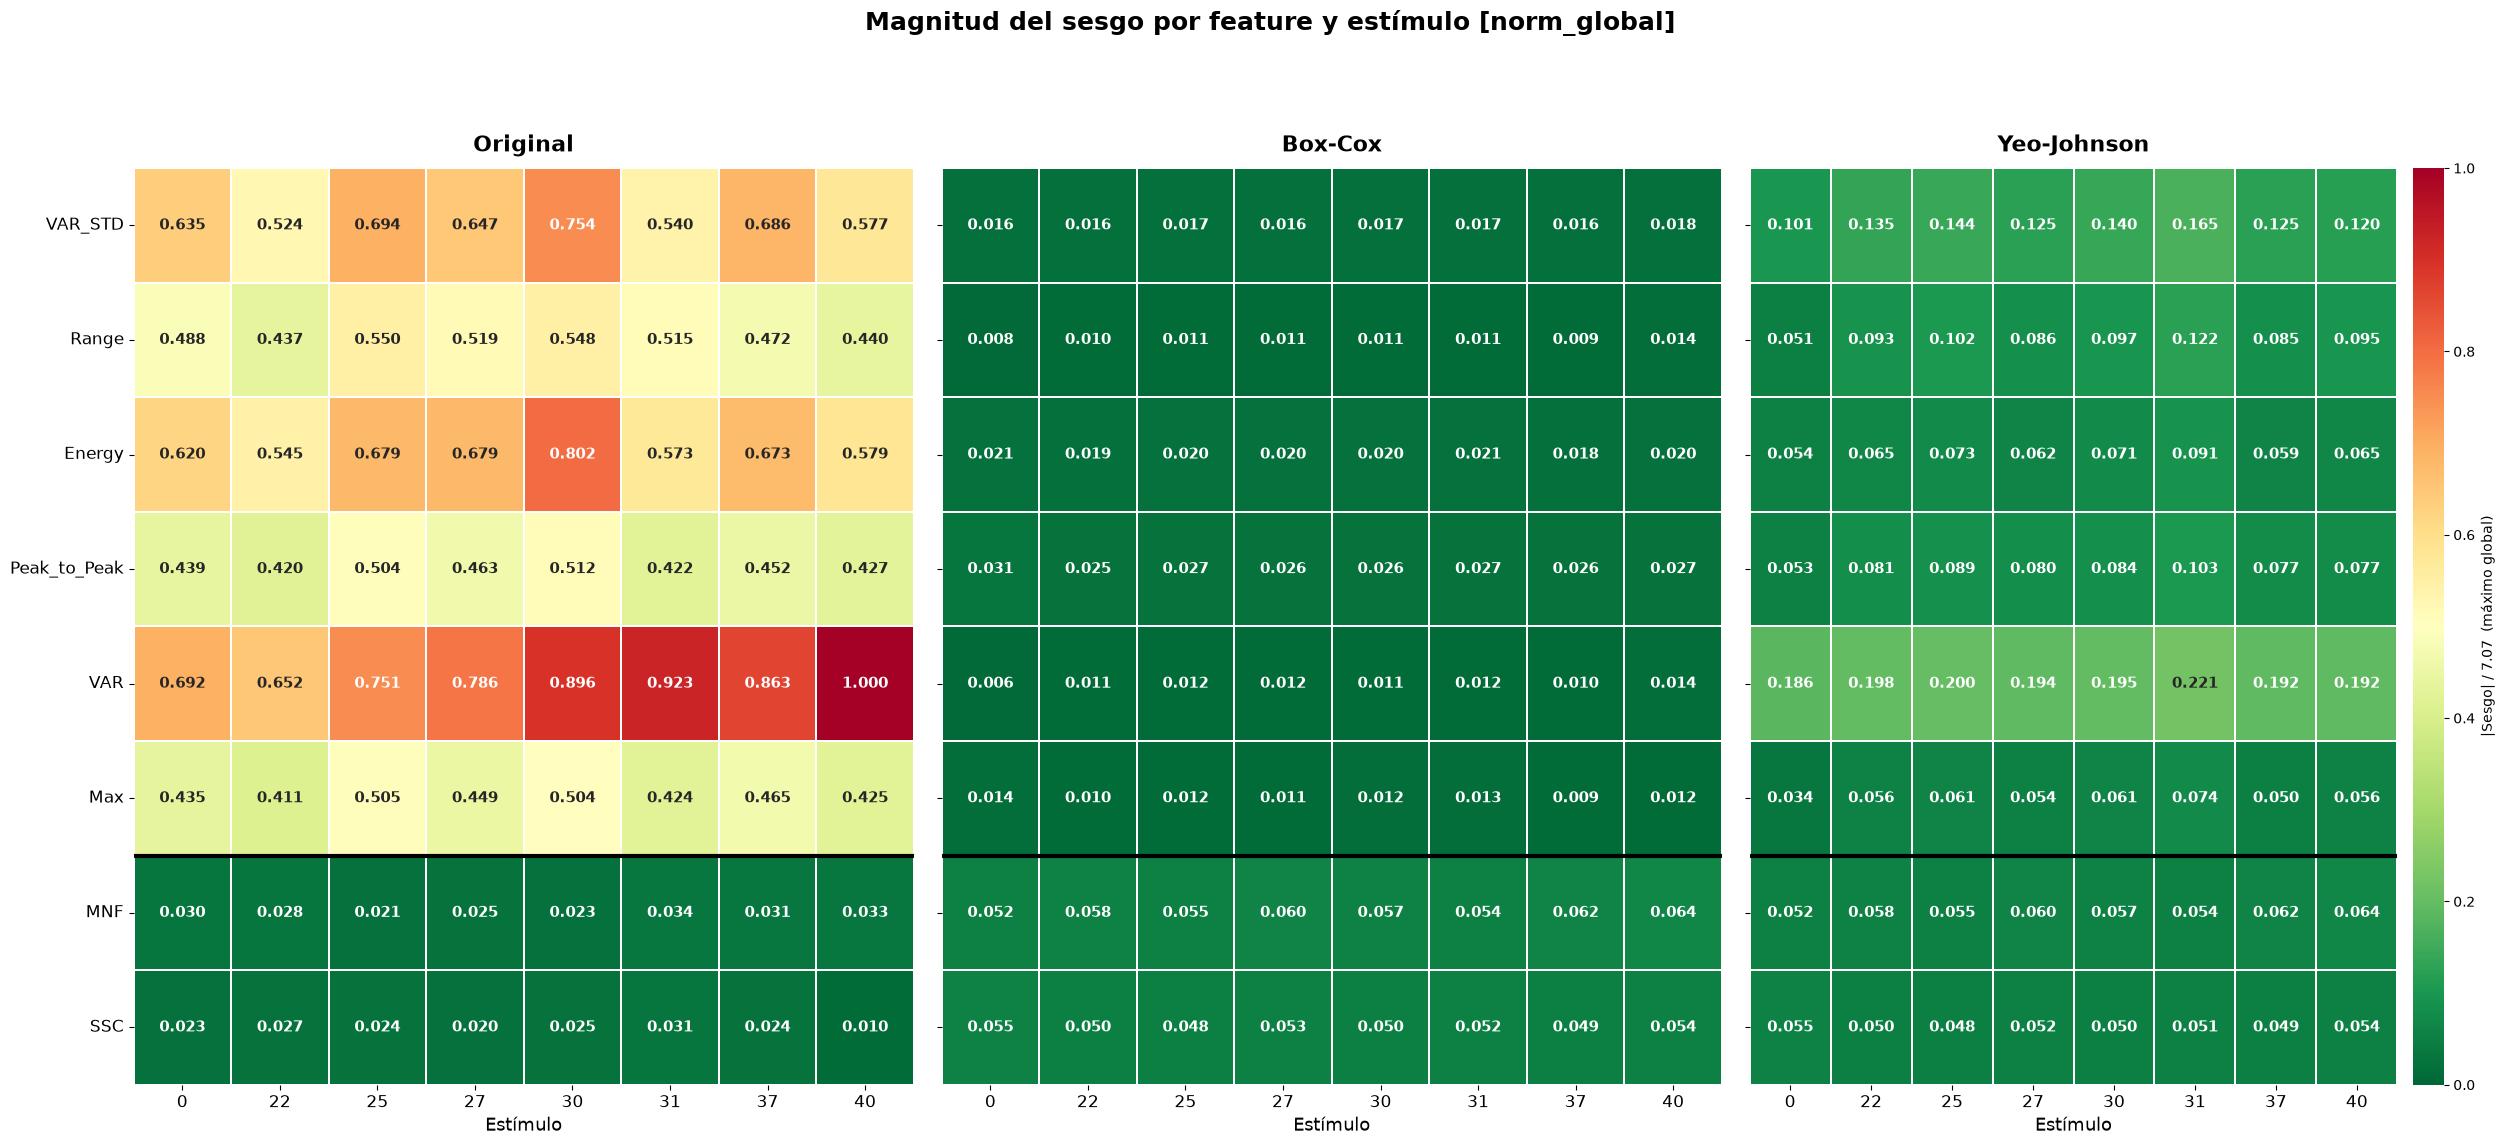

In [23]:
heatmap_sesgo(df_comparacion_max, FEATURES, modo='norm_global')

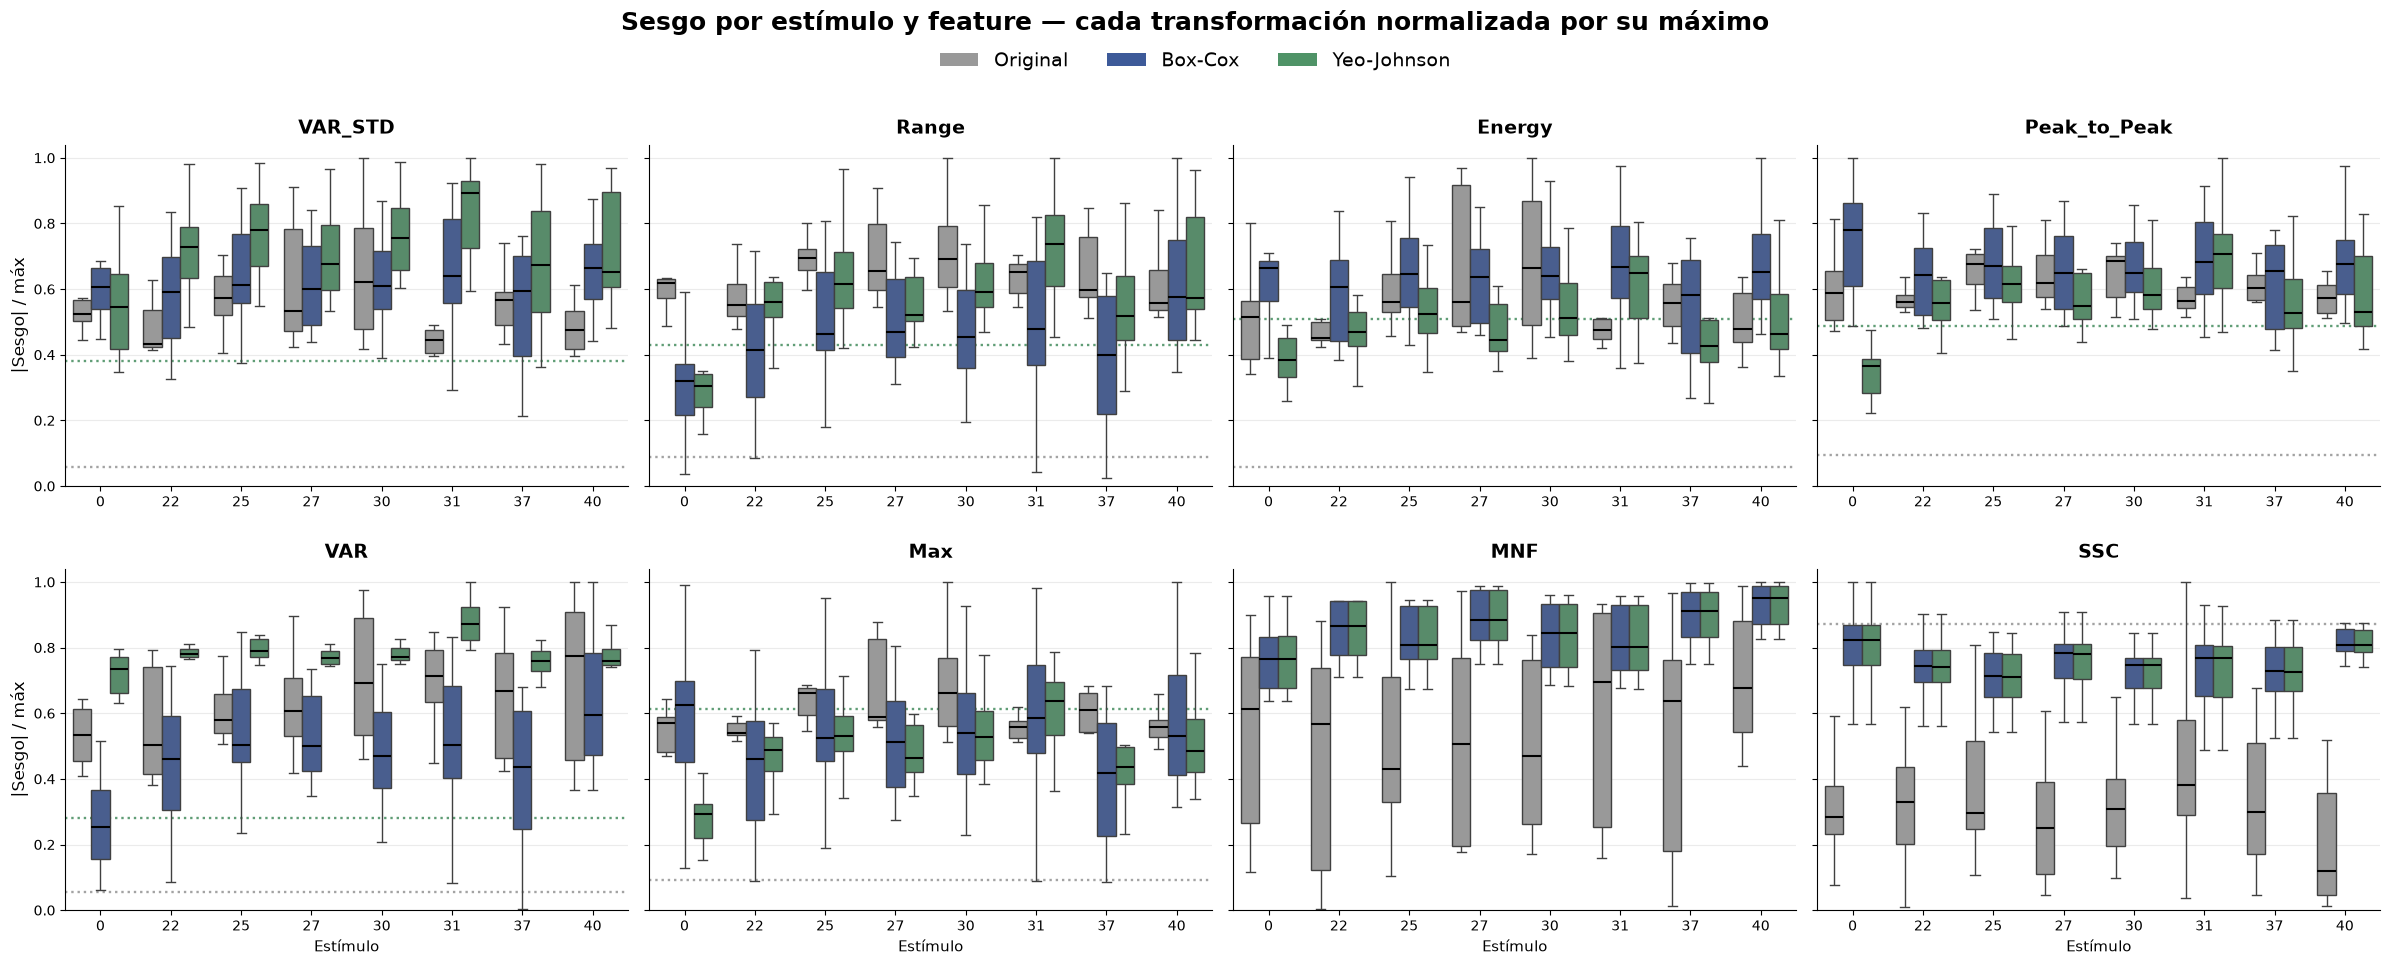

In [24]:
boxplot_sesgo_por_feature(df_comparacion_max, FEATURES)

Excluidos (|sesgo original| < 0.3): MNF, SSC


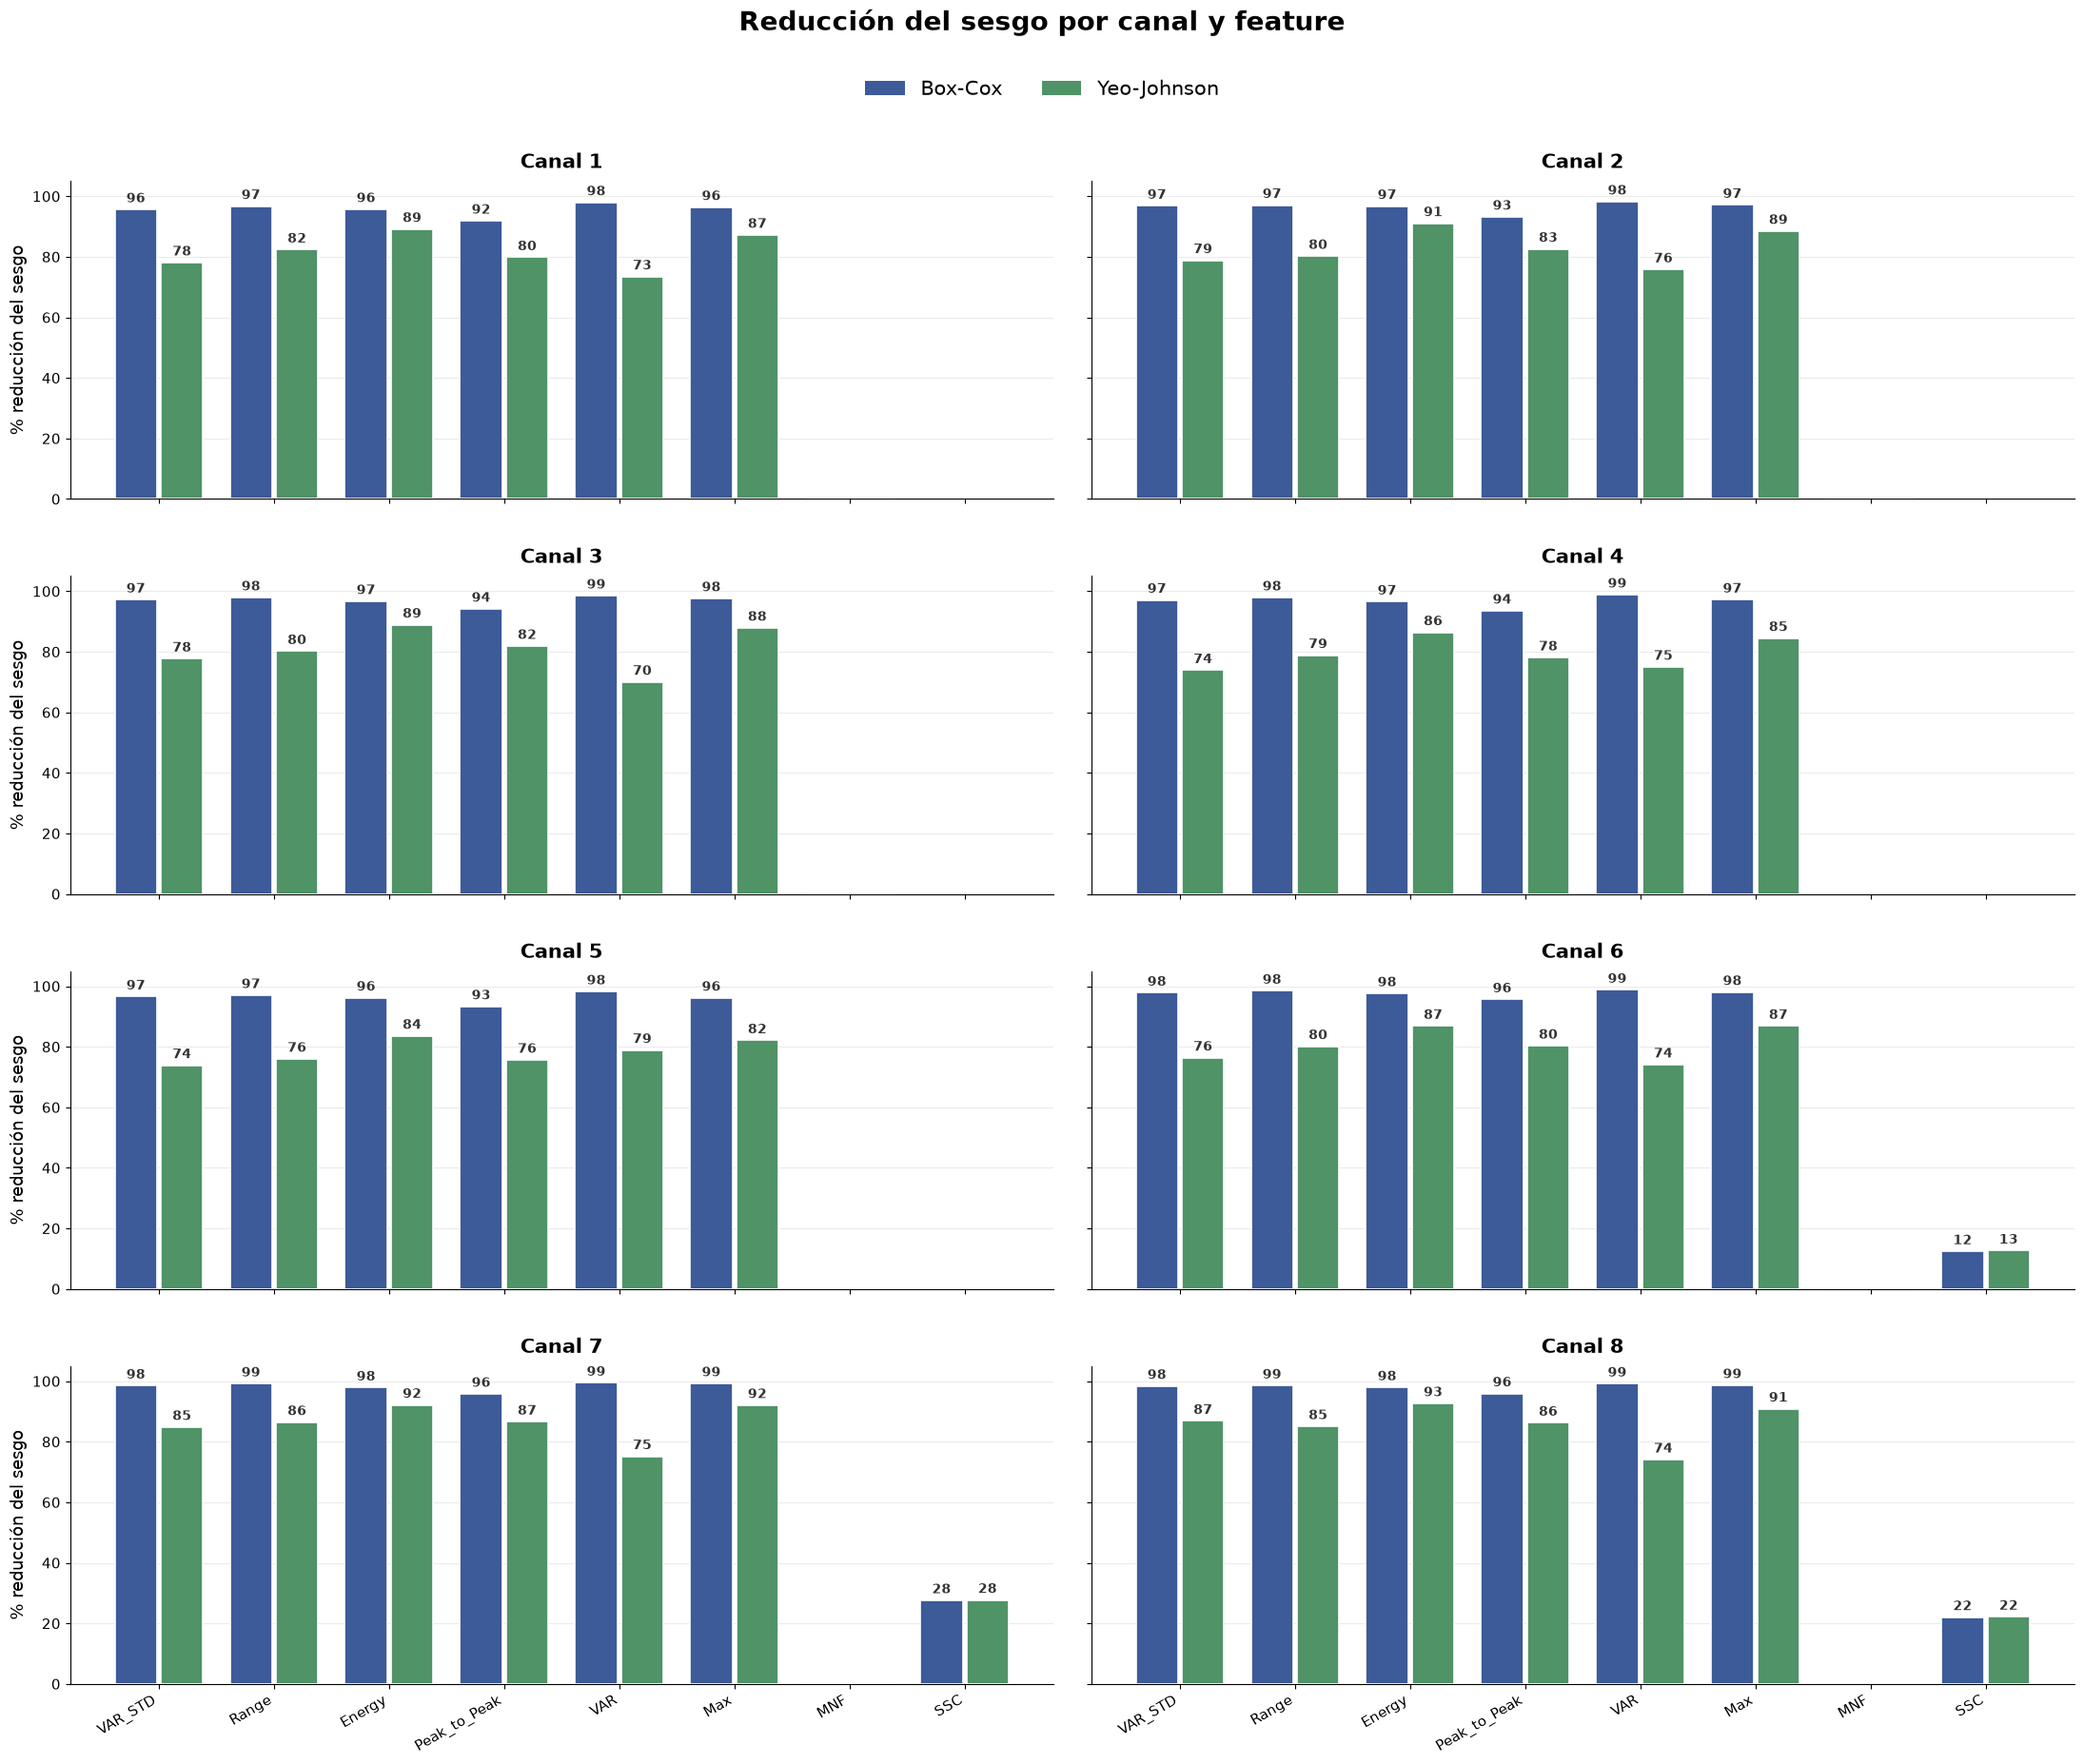

In [25]:
barras_reduccion(df_comparacion_max, FEATURES)